In [12]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.linear_model import LogisticRegression

In [13]:

df = pd.read_csv(R'C:\Users\vagee\OneDrive\Attachments\Desktop\ml\New folder\loan_data (1).csv')

In [14]:
print(df.shape)


(9578, 14)


In [24]:
df.info


<bound method DataFrame.info of       credit.policy             purpose  int.rate  installment  \
0                 1  debt_consolidation    0.1189       829.10   
1                 1         credit_card    0.1071       228.22   
2                 1  debt_consolidation    0.1357       366.86   
3                 1  debt_consolidation    0.1008       162.34   
4                 1         credit_card    0.1426       102.92   
...             ...                 ...       ...          ...   
9573              0           all_other    0.1461       344.76   
9574              0           all_other    0.1253       257.70   
9575              0  debt_consolidation    0.1071        97.81   
9576              0    home_improvement    0.1600       351.58   
9577              0  debt_consolidation    0.1392       853.43   

      log.annual.inc    dti  fico  days.with.cr.line  revol.bal  revol.util  \
0          11.350407  19.48   737        5639.958333      28854        52.1   
1          11.082

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
print(df.columns.tolist())

['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']


In [31]:
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']


In [34]:
X = pd.get_dummies(X, columns=['purpose'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print("Preprocessing done!")


Train size: (7662, 18)
Test size: (1916, 18)
Preprocessing done!


In [35]:
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [36]:
print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.2f}")

              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1609
           1       0.24      0.57      0.34       307

    accuracy                           0.64      1916
   macro avg       0.56      0.61      0.55      1916
weighted avg       0.78      0.64      0.69      1916

AUC Score: 0.68


In [ ]:
# Visualizations

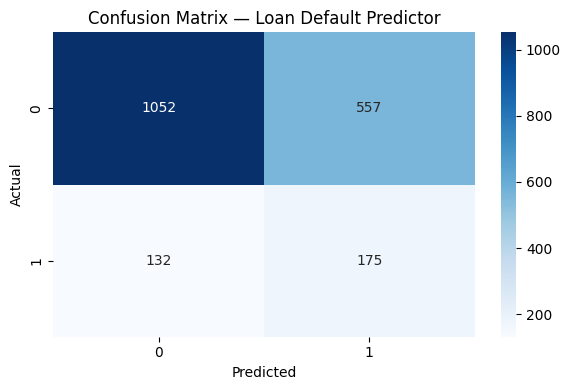

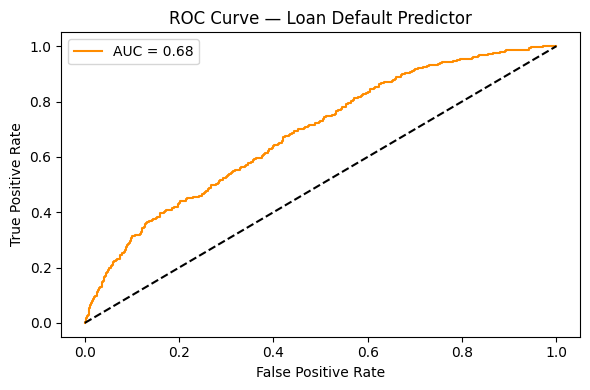

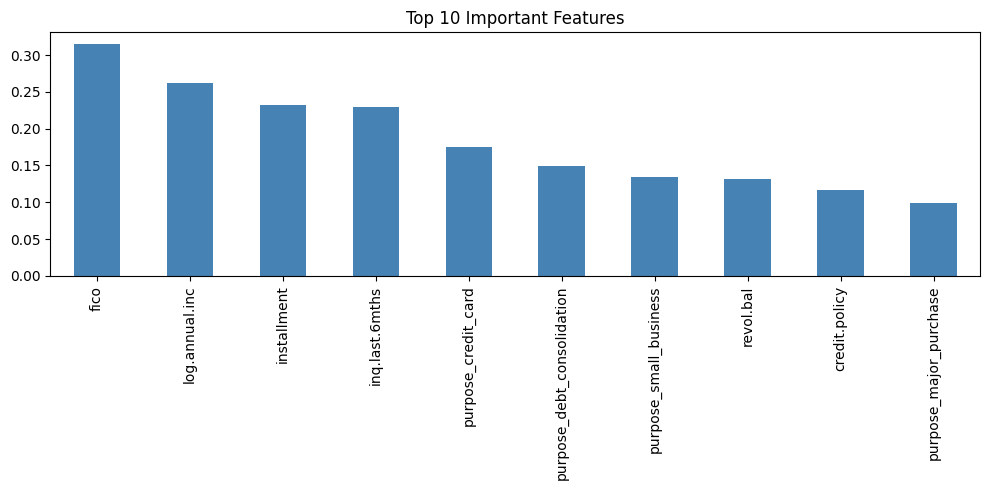

In [37]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Loan Default Predictor')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Loan Default Predictor')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

#  Feature Importance
feature_names = X.columns
importance = pd.Series(
    np.abs(model.coef_[0]),
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance[:10].plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


2026-03-01 23:38:58.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 23:38:58.578 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 23:38:58.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 23:38:58.585 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 23:38:58.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


FileNotFoundError: [Errno 2] No such file or directory: 'loan_data.csv'